# Logistic regression from scratch

A six-point synthetic example of logistic loss and gradient descent. The numerical implementation lives in `ml_fundamentals/linear.py` and has finite-difference gradient tests. This notebook was revised with AI assistance; see `docs/CHANGELOG.md`.


In [1]:
from pathlib import Path
import sys
root = Path.cwd()
if not (root / 'ml_fundamentals').exists():
    root = root.parent
if not (root / 'ml_fundamentals').exists():
    raise RuntimeError('Start Jupyter from the repository root')
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
import numpy as np
import matplotlib.pyplot as plt

from ml_fundamentals.linear import fit_logistic,predict_logistic
X=np.array([[2,1],[3,2],[4,4],[1,5],[2,6],[3,7]],dtype=float)
y=np.array([1,1,1,0,0,0])


The loss is mean binary cross-entropy computed from logits with `logaddexp` for numerical stability. Stop when the gradient norm is below 1e-6 or the iteration budget is exhausted. A separating line is not evidence that the loss has converged. Unregularised logistic regression on separable data need not have a finite minimiser.


learning_rate=0.01; iterations=1000; loss=0.058146; gradient_norm=0.075817; converged=False; training_accuracy=1.000
learning_rate=0.1; iterations=1000; loss=0.005818; gradient_norm=0.007596; converged=False; training_accuracy=1.000


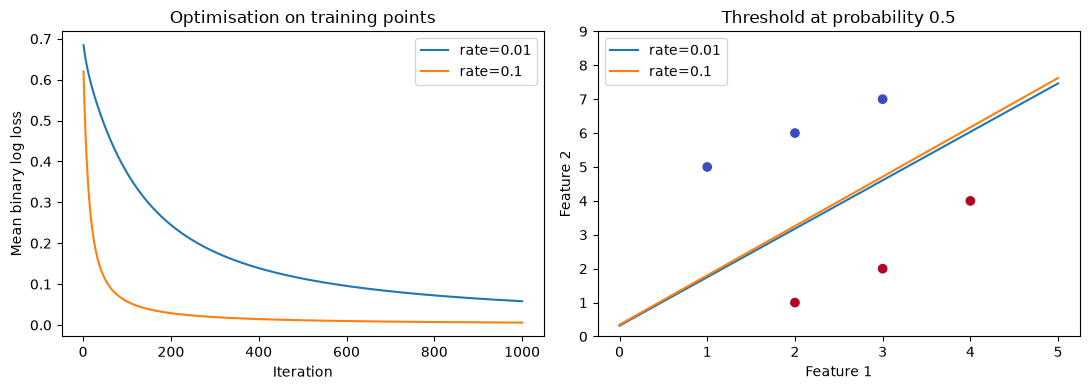

In [2]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
for rate in [0.01,0.1]:
    weights,history,converged=fit_logistic(X,y,learning_rate=rate,max_iterations=1000)
    accuracy=float(np.mean(predict_logistic(X,weights)==y))
    print(f'learning_rate={rate}; iterations={len(history)}; loss={history[-1]["loss"]:.6f}; gradient_norm={history[-1]["gradient_norm"]:.6f}; converged={converged}; training_accuracy={accuracy:.3f}')
    axes[0].plot([h['iteration'] for h in history],[h['loss'] for h in history],label=f'rate={rate}')
    xx=np.linspace(0,5,100)
    if abs(weights[2])>1e-12:
        axes[1].plot(xx,-(weights[0]+weights[1]*xx)/weights[2],label=f'rate={rate}')
    elif abs(weights[1])>1e-12:
        axes[1].axvline(-weights[0]/weights[1],label=f'rate={rate}')
axes[0].set(xlabel='Iteration',ylabel='Mean binary log loss',title='Optimisation on training points')
axes[1].scatter(X[:,0],X[:,1],c=y,cmap='coolwarm')
axes[1].set(xlabel='Feature 1',ylabel='Feature 2',ylim=(0,9),title='Threshold at probability 0.5')
for ax in axes:ax.legend()
plt.tight_layout();plt.show()


Both runs use the same six training points and zero initial weights. Learning-rate behaviour is specific to feature scale and this dataset. No test accuracy or claim of real-world classification quality is made.
